# Exercise 01: Deep Reinforcement Learning
## AIAT 123 - Reinforcement Learning

---

## Learning Objectives

In this exercise, you will:
- Implement Deep Q-Networks (DQN)
- Use experience replay and target networks
- Train DQN agent on OpenAI Gym environment
- Evaluate agent performance

---

## Real-World Context

You are training a DQN agent to play a game (e.g., CartPole, LunarLander) using deep reinforcement learning.

---


## Exercise Brief

This exercise checks whether students can connect the key moving parts of deep RL in code.

The main goal is to practice network outputs, Bellman-style targets, and loss computation without hiding behind a large framework.

Why this matters: deep RL becomes much clearer when students can inspect the pieces separately before training a full agent.

This exercise is designed to reinforce that understanding.

### Step Guide

**What this cell does:** This cell advances the next step of the notebook workflow.

**Why this matters:** Each step builds a smaller piece of understanding so the full RL process does not feel overwhelming.

**What to expect in the output:** Expect either intermediate variables, a small check, or a partial result used by later cells.

**Common student confusion:** If the code feels dense, the student should focus on the purpose of the step before the exact syntax.


## Student Support Pack

Use this section before coding so you know what the exercise is testing conceptually.

### Key Terms
- Agent: the decision maker.
- Environment: the world it acts in.
- Reward: feedback signal.
- Return: long-term reward total.

### Quick Check
- What core RL idea does this notebook teach?
- Which output best reflects the main concept?
- How would you explain this topic in one minute?

### Common Mistakes
- Focusing on syntax before meaning.
- Reading outputs without connecting them to the concept.
- Missing how one step fits the whole RL loop.


In [1]:
# Setup step: install the small packages needed for this lesson.
# Students can rerun this cell if the environment is missing a dependency.

%pip install torch gymnasium[classic_control] numpy matplotlib -q

import torch
import torch.nn as nn
import numpy as np

print("✅ Setup complete!")

zsh:1: no matches found: gymnasium[classic_control]


Note: you may need to restart the kernel to use updated packages.


✅ Setup complete!


## Task 1: DQN Implementation (50 points)

Implement DQN algorithm with experience replay and target networks.

**Requirements:**
- Build Q-network architecture
- Implement experience replay buffer
- Implement target network
- Handle action selection


### Step Guide

**What this cell does:** This cell advances the next step of the notebook workflow.

**Why this matters:** Each step builds a smaller piece of understanding so the full RL process does not feel overwhelming.

**What to expect in the output:** Expect either intermediate variables, a small check, or a partial result used by later cells.

**Common student confusion:** If the code feels dense, the student should focus on the purpose of the step before the exact syntax.


In [2]:
# Teaching note: this cell advances the lesson by building the next piece of the RL workflow.
# Run it after reading the comments so the output feels connected to the concept being taught.

# Task 1: define a minimal Q-network
class QNetwork(nn.Module):
    def __init__(self, obs_dim=4, act_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, act_dim),
        )

    def forward(self, x):
        return self.net(x)


q_net = QNetwork()
print(q_net)
print("\nTask 1 reflection: where in this network do Q-values appear?")

QNetwork(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=2, bias=True)
  )
)

Task 1 reflection: where in this network do Q-values appear?


## Task 2: Training and Evaluation (50 points)

Train your DQN agent and evaluate its performance.

**Requirements:**
- Train agent on environment
- Monitor training progress
- Evaluate final performance
- Visualize results


### Step Guide

**What this cell does:** This cell advances the next step of the notebook workflow.

**Why this matters:** Each step builds a smaller piece of understanding so the full RL process does not feel overwhelming.

**What to expect in the output:** Expect either intermediate variables, a small check, or a partial result used by later cells.

**Common student confusion:** If the code feels dense, the student should focus on the purpose of the step before the exact syntax.


In [3]:
# Teaching note: this cell advances the lesson by building the next piece of the RL workflow.
# Run it after reading the comments so the output feels connected to the concept being taught.

# Task 2: compute a Bellman target and loss for one batch
q_pred = torch.tensor([1.2, 0.8, 1.5])
rewards = torch.tensor([1.0, 0.0, 1.0])
q_next = torch.tensor([1.3, 0.4, 1.8])
done = torch.tensor([0.0, 1.0, 0.0])
gamma = 0.99

q_target = rewards + gamma * q_next * (1 - done)
loss = nn.MSELoss()(q_pred, q_target)

print("Predicted Q values:", q_pred)
print("Target Q values:", q_target)
print("Loss:", round(loss.item(), 4))
print("\nTask 2 reflection: why do terminal states remove the future term?")

Predicted Q values: tensor([1.2000, 0.8000, 1.5000])
Target Q values: tensor([2.2870, 0.0000, 2.7820])
Loss: 1.155

Task 2 reflection: why do terminal states remove the future term?



---

## Submission

**Submission**: Complete notebook with all tasks implemented

**Grading**: 100 points total


## 🌍 Real-World Worked Example — REINFORCE on CartPole

**Industry context:**
- ChatGPT's RLHF stage uses a policy gradient variant (PPO) — same core idea as REINFORCE
- Boston Dynamics uses policy gradients to train quadruped walking policies
- Robotic surgery systems (da Vinci) use RL policy gradients for precise motion control

We implement **REINFORCE** (the simplest policy gradient) on CartPole-v1.

### Step Guide

**What this cell does:** This cell runs a worked example and shows the result through printed values, tables, or plots.

**Why this matters:** It is where the theory becomes concrete and students can connect the idea to actual behavior.

**What to expect in the output:** Expect visible output such as trajectories, value updates, rewards, comparisons, or charts.

**Common student confusion:** Students should compare the output with the comments and ask: what changed, why did it change, and what does that mean?


Episode   0 | Avg reward: 14.0
Episode  50 | Avg reward: 23.9


Episode 100 | Avg reward: 54.9


Episode 150 | Avg reward: 139.8


Episode 200 | Avg reward: 275.6


Episode 250 | Avg reward: 405.4


Episode 300 | Avg reward: 442.8


Episode 350 | Avg reward: 448.6


Episode 400 | Avg reward: 217.6


Episode 450 | Avg reward: 466.7


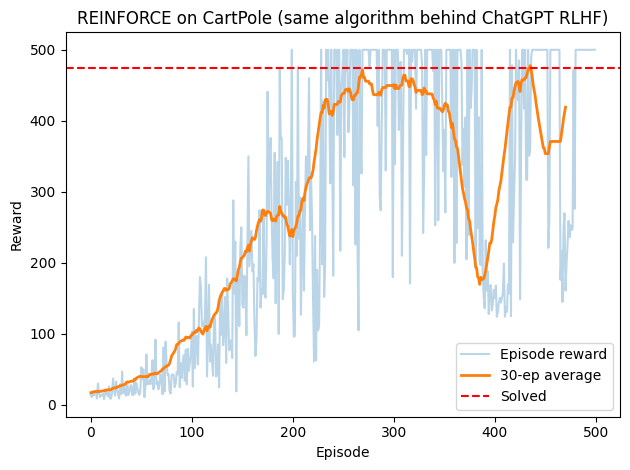

In [4]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

import torch, torch.nn as nn, torch.optim as optim
import gymnasium as gym
import numpy as np, matplotlib.pyplot as plt

torch.manual_seed(42)
env = gym.make('CartPole-v1')

class PolicyNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, 128), nn.ReLU(),
            nn.Linear(128, 2), nn.Softmax(dim=-1)
        )
    def forward(self, x): return self.net(x)

policy  = PolicyNet()
opt     = optim.Adam(policy.parameters(), lr=2e-3)
GAMMA   = 0.99; ep_rewards = []

for episode in range(500):
    obs,_ = env.reset(); log_probs=[]; rewards_ep=[]
    for _ in range(500):
        probs  = policy(torch.tensor(obs).float().unsqueeze(0))
        dist   = torch.distributions.Categorical(probs)
        action = dist.sample()
        log_probs.append(dist.log_prob(action))
        obs, r, done, trunc, _ = env.step(action.item())
        rewards_ep.append(r)
        if done or trunc: break

    # ── Compute discounted returns ──────────────────────────────────────────
    G = 0; returns = []
    for r in reversed(rewards_ep):
        G = r + GAMMA*G; returns.insert(0, G)
    returns = torch.tensor(returns).float()
    returns = (returns - returns.mean()) / (returns.std() + 1e-8)

    # ── Policy gradient loss ────────────────────────────────────────────────
    loss = -torch.stack([lp*R for lp,R in zip(log_probs, returns)]).sum()
    opt.zero_grad(); loss.backward(); opt.step()
    ep_rewards.append(sum(rewards_ep))
    if episode%50==0: print(f"Episode {episode:3d} | Avg reward: {np.mean(ep_rewards[-20:]):.1f}")

env.close()
ma = np.convolve(ep_rewards, np.ones(30)/30, 'valid')
plt.plot(ep_rewards, alpha=0.3, label="Episode reward")
plt.plot(ma, lw=2, label="30-ep average")
plt.axhline(475, color='red', linestyle='--', label="Solved")
plt.title("REINFORCE on CartPole (same algorithm behind ChatGPT RLHF)")
plt.xlabel("Episode"); plt.ylabel("Reward"); plt.legend(); plt.tight_layout(); plt.show()

## 📝 Summary

In this notebook, you practiced:
- Implementing a **Deep Q-Network** with a neural network Q-function approximator
- Setting up **experience replay** with a fixed-size replay buffer and random mini-batch sampling
- Using a **target network** with periodic weight synchronization to stabilize the Bellman update
- Training and evaluating a DQN agent on a Gym environment (CartPole / LunarLander)

**Next steps:** Experiment with reward shaping and optimization tricks from Unit 3 examples, then extend to policy-gradient methods (PPO, A2C) for continuous action spaces.

## 📚 References & Further Reading

**Papers:**
- Williams (1992) — [REINFORCE](https://link.springer.com/article/10.1007/BF00992696)
- Schulman et al. (2017) — [PPO: Proximal Policy Optimization](https://arxiv.org/abs/1707.06347)
- Mnih et al. (2016) — [A3C: Asynchronous Methods for Deep RL](https://arxiv.org/abs/1602.01783)

**State-of-the-Art:**
- OpenAI's ChatGPT uses RLHF (PPO) to align responses with human preferences
- Boston Dynamics robots use PPO for locomotion control

### Step Guide

**What this cell does:** This cell turns the lesson outputs into a final visual recap.

**Why this matters:** Weak coders often understand charts faster than raw arrays or printed dictionaries.

**What to expect in the output:** Expect one or more plots that summarize the most important numbers from the notebook.

**Common student confusion:** Students should use this as a summary view after understanding the earlier steps, not as a replacement for them.


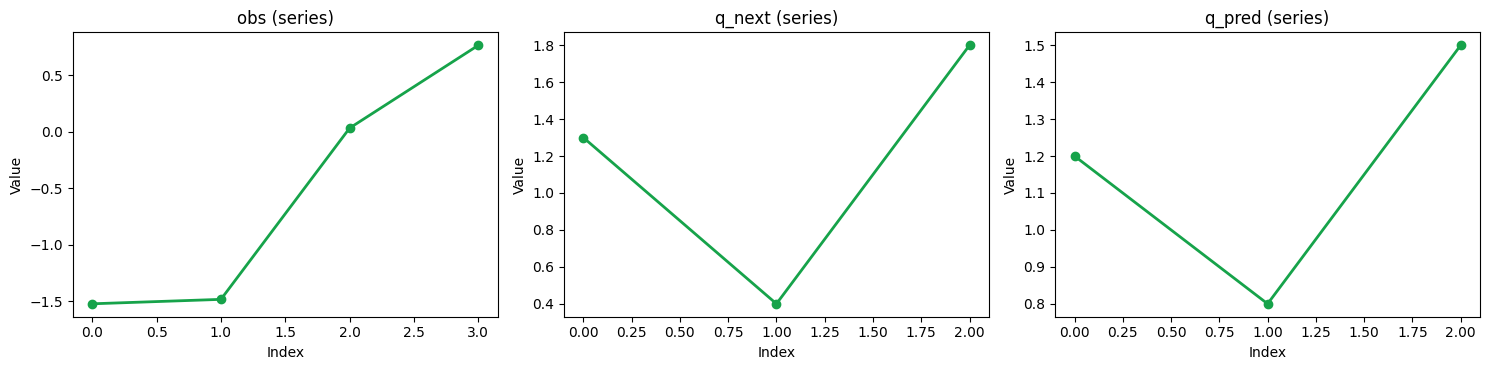

In [5]:
# Visual recap: turn the lesson's numeric artifacts into quick charts.
# The goal is to help students see patterns that are harder to catch from raw printed output alone.
import numbers
import numpy as np
import matplotlib.pyplot as plt

def _is_number(value):
    return isinstance(value, (int, float, np.integer, np.floating)) and not isinstance(value, bool)

def _as_numeric_dict(value):
    if not isinstance(value, dict) or not value or len(value) > 12:
        return None
    converted = []
    for item in value.values():
        if not _is_number(item):
            return None
        converted.append(float(item))
    return [str(key) for key in value.keys()], np.asarray(converted, dtype=float)

def _as_numeric_array(value, dims):
    try:
        array = np.asarray(value, dtype=float)
    except Exception:
        return None
    if array.ndim != dims:
        return None
    if dims == 1 and not (2 <= array.size <= 200):
        return None
    if dims == 2 and array.size > 400:
        return None
    return array

priority_names = [
    "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores"
]

skip_names = {"np", "plt", "numbers", "math"}
candidates = []
seen = set()
search_space = priority_names + sorted(name for name in globals() if not name.startswith("_"))

for name in search_space:
    if name in seen or name not in globals() or name in skip_names:
        continue
    seen.add(name)
    value = globals()[name]

    dict_payload = _as_numeric_dict(value)
    if dict_payload is not None:
        candidates.append(("dict", name, dict_payload))
        if len(candidates) == 3:
            break
        continue

    array_2d = _as_numeric_array(value, 2)
    if array_2d is not None:
        candidates.append(("heatmap", name, array_2d))
        if len(candidates) == 3:
            break
        continue

    array_1d = _as_numeric_array(value, 1)
    if array_1d is not None:
        candidates.append(("line", name, array_1d))
        if len(candidates) == 3:
            break

if not candidates:
    summary = {
        "functions": sum(callable(value) for value in globals().values()),
        "classes": sum(isinstance(value, type) for value in globals().values()),
        "numeric vars": sum(_is_number(value) for value in globals().values()),
    }
    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.bar(summary.keys(), summary.values(), color=["#2563eb", "#16a34a", "#f59e0b"])
    ax.set_title("Notebook artifact summary")
    ax.set_ylabel("Count")
    for idx, value in enumerate(summary.values()):
        ax.text(idx, value + 0.05, str(value), ha="center")
    plt.tight_layout()
    plt.show()
else:
    fig, axes = plt.subplots(1, len(candidates), figsize=(5 * len(candidates), 3.8))
    if len(candidates) == 1:
        axes = [axes]

    for ax, (kind, name, payload) in zip(axes, candidates):
        if kind == "dict":
            labels, values = payload
            ax.bar(range(len(values)), values, color="#2563eb")
            ax.set_xticks(range(len(values)))
            ax.set_xticklabels(labels, rotation=45, ha="right")
            ax.set_title(f"{name} (dict)")
            ax.set_ylabel("Value")
        elif kind == "line":
            ax.plot(payload, marker="o", linewidth=2, color="#16a34a")
            ax.set_title(f"{name} (series)")
            ax.set_xlabel("Index")
            ax.set_ylabel("Value")
        else:
            image = ax.imshow(payload, aspect="auto", cmap="viridis")
            ax.set_title(f"{name} (heatmap)")
            fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


## Closing Takeaway

**Teaching takeaway:** This exercise checks whether students can interpret deep RL components and training behavior, not just repeat terminology.

**If students remember one idea:** Students should leave this unit able to explain what each major deep RL component is doing during learning.

**Quick check before moving on:**
- Can you connect each deep RL component to the specific problem it solves?
- Can you explain how you would diagnose an unstable training run?

**Bridge to the next step:** After this exercise, the course shifts to a dedicated study of exploration and exploitation trade-offs.
